In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import VotingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

In [58]:
df = pd.read_csv(r"D:\GitHubRepos\is6400-business-data-analytics\data\cleaned_loan_data.csv")
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4,586,No,1
5,21,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2,532,No,1
6,26,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3,701,No,1
7,24,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4,585,No,1
8,24,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2,544,No,1
9,21,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3,640,No,1


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42776 entries, 0 to 42775
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      42776 non-null  int64  
 1   person_gender                   42776 non-null  object 
 2   person_education                42776 non-null  object 
 3   person_income                   42776 non-null  float64
 4   person_emp_exp                  42776 non-null  int64  
 5   person_home_ownership           42776 non-null  object 
 6   loan_amnt                       42776 non-null  float64
 7   loan_intent                     42776 non-null  object 
 8   loan_int_rate                   42776 non-null  float64
 9   loan_percent_income             42776 non-null  float64
 10  cb_person_cred_hist_length      42776 non-null  int64  
 11  credit_score                    42776 non-null  int64  
 12  previous_loan_defaults_on_file  

In [60]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000
mean,27.609056,70852.732443,5.262741,9275.487586,10.993112,0.143362,5.780251,632.323523,0.229100
std,5.830140,32447.846522,5.840831,6041.753786,2.975452,0.087443,3.825896,50.403992,0.420259
min,20.000000,8000.000000,0.000000,500.000000,5.420000,0.010000,2.000000,390.000000,0.000000
25%,24.000000,46149.000000,1.000000,5000.000000,8.590000,0.080000,3.000000,601.000000,0.000000
50%,26.000000,65645.500000,4.000000,8000.000000,11.010000,0.130000,4.000000,639.000000,0.000000
75%,30.000000,90756.250000,8.000000,12000.000000,12.990000,0.190000,8.000000,669.000000,0.000000
max,78.000000,168633.000000,58.000000,35000.000000,20.000000,0.660000,30.000000,784.000000,1.000000


In [ ]:
# 数据预处理
def preprocess_data(df):
    # 负债收入比
    df['debt_income_ratio'] = df['loan_amnt'] / (df['person_income'] + 1e-6)
    # 信用历史密度
    df['credit_density'] = df['cb_person_cred_hist_length'] / (df['person_age'] - 18)
    # 贷款金额与收入占比
    df['loan_income_percent'] = df['loan_amnt'] * df['loan_percent_income']
    # 工作经验分段
    df['emp_exp_bin'] = pd.cut(df['person_emp_exp'], bins=[-1, 0, 3, 10, 50], labels=['No experience', 'Elementary', 'Senior', 'Expert'])
    # 处理分类变量
    df = pd.get_dummies(df, columns=['person_education', 'person_home_ownership', 'loan_intent', 'emp_exp_bin'])
    df['person_gender'] = df['person_gender'].map({'male':0, 'female':1})
    df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'No':0, 'Yes':1})

    return df

In [73]:
df_clean = preprocess_data(df)

In [75]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42776 entries, 0 to 42775
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      42776 non-null  int64  
 1   person_gender                   42776 non-null  int64  
 2   person_income                   42776 non-null  float64
 3   person_emp_exp                  42776 non-null  int64  
 4   loan_amnt                       42776 non-null  float64
 5   loan_int_rate                   42776 non-null  float64
 6   loan_percent_income             42776 non-null  float64
 7   cb_person_cred_hist_length      42776 non-null  int64  
 8   credit_score                    42776 non-null  int64  
 9   previous_loan_defaults_on_file  42776 non-null  int64  
 10  loan_status                     42776 non-null  int64  
 11  debt_income_ratio               42776 non-null  float64
 12  credit_density                  

In [74]:
df_clean.head(10)

,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,...,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,emp_exp_bin_No experience,emp_exp_bin_Elementary,emp_exp_bin_Senior,emp_exp_bin_Expert
0,22,1,71948.0,0,35000.0,16.02,0.49,3,561,0,...,False,False,False,False,True,False,True,False,False,False
1,21,1,12282.0,0,1000.0,11.14,0.08,2,504,1,...,False,True,False,False,False,False,True,False,False,False
2,25,1,12438.0,3,5500.0,12.87,0.44,3,635,0,...,False,False,False,True,False,False,False,True,False,False
3,23,1,79753.0,0,35000.0,15.23,0.44,2,675,0,...,False,False,False,True,False,False,True,False,False,False
4,24,0,66135.0,1,35000.0,14.27,0.53,4,586,0,...,False,False,False,True,False,False,False,True,False,False
5,21,1,12951.0,0,2500.0,7.14,0.19,2,532,0,...,False,False,False,False,False,True,True,False,False,False
6,26,1,93471.0,1,35000.0,12.42,0.37,3,701,0,...,False,True,False,False,False,False,False,True,False,False
7,24,1,95550.0,5,35000.0,11.11,0.37,4,585,0,...,False,False,False,True,False,False,False,False,True,False
8,24,1,100684.0,3,35000.0,8.90,0.35,2,544,0,...,False,False,False,False,True,False,False,True,False,False
9,21,1,12739.0,0,1600.0,14.74,0.13,3,640,0,...,False,False,False,False,False,True,True,False,False,False


In [64]:
# 划分数据集
X = df_clean.drop('loan_status', axis=1)
y = df_clean['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [65]:
# XGBoost参数调优
xgb_param_grid = {
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.05, 0.3),  # 0.05~0.35
    'subsample': uniform(0.6, 0.4),      # 0.6~1.0
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 1),             # 0~1
    'reg_alpha': uniform(0, 10)         # L1正则化
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='auc',
        random_state=42
    ),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print("XGBoost最佳参数:", xgb_search.best_params_)

# AdaBoost参数调优
adb_param_grid = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.1, 0.9),  # 0.1~1.0
    'estimator__max_depth': randint(2, 5)  # 基学习器参数
}

adb_search = RandomizedSearchCV(
    estimator=AdaBoostClassifier(
        estimator=DecisionTreeClassifier(),
        random_state=42
    ),
    param_distributions=adb_param_grid,
    n_iter=20,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

adb_search.fit(X_train, y_train)
best_adb = adb_search.best_estimator_
print("AdaBoost最佳参数:", adb_search.best_params_)

# CatBoost参数调优
catb_param_grid = {
    'depth': randint(4, 10),
    'learning_rate': uniform(0.05, 0.3),
    'l2_leaf_reg': uniform(1, 10),      # 1~11
    'border_count': [32, 64, 128, 254]
}

catb_search = RandomizedSearchCV(
    estimator=CatBoostClassifier(
        cat_features=X_train.select_dtypes('object').columns.tolist(),
        auto_class_weights='Balanced',
        iterations=300,
        verbose=0,
        random_state=42
    ),
    param_distributions=catb_param_grid,
    n_iter=20,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

catb_search.fit(X_train, y_train)
best_catb = catb_search.best_estimator_
print("CatBoost最佳参数:", catb_search.best_params_)

XGBoost最佳参数: {'colsample_bytree': 0.6953272269721071, 'gamma': 0.012118909938421352, 'learning_rate': 0.3289451298749464, 'max_depth': 6, 'reg_alpha': 3.8199675449960013, 'subsample': 0.8041553093436555}
AdaBoost最佳参数: {'estimator__max_depth': 4, 'learning_rate': 0.6348116621258276, 'n_estimators': 122}
CatBoost最佳参数: {'border_count': 254, 'depth': 9, 'l2_leaf_reg': 6.7000675683012965, 'learning_rate': 0.18038258056311146}


In [66]:
optimized_voting = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('adb', best_adb),
        ('catb', best_catb)
    ],
    voting='soft',
    n_jobs=-1
)

In [67]:
# 训练与评估流程
models = {
    'Optimized_XGBoost': best_xgb,
    'Optimized_AdaBoost': best_adb,
    'Optimized_CatBoost': best_catb,
    'Optimized_Ensemble': optimized_voting
}
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))


=== Training Optimized_XGBoost ===

Optimized_XGBoost Performance:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      6596
           1       0.78      0.90      0.84      1960

    accuracy                           0.92      8556
   macro avg       0.87      0.91      0.89      8556
weighted avg       0.93      0.92      0.92      8556


=== Training Optimized_AdaBoost ===

Optimized_AdaBoost Performance:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      6596
           1       0.86      0.79      0.82      1960

    accuracy                           0.92      8556
   macro avg       0.90      0.87      0.88      8556
weighted avg       0.92      0.92      0.92      8556


=== Training Optimized_CatBoost ===

Optimized_CatBoost Performance:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      6596
           1       0.81      

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

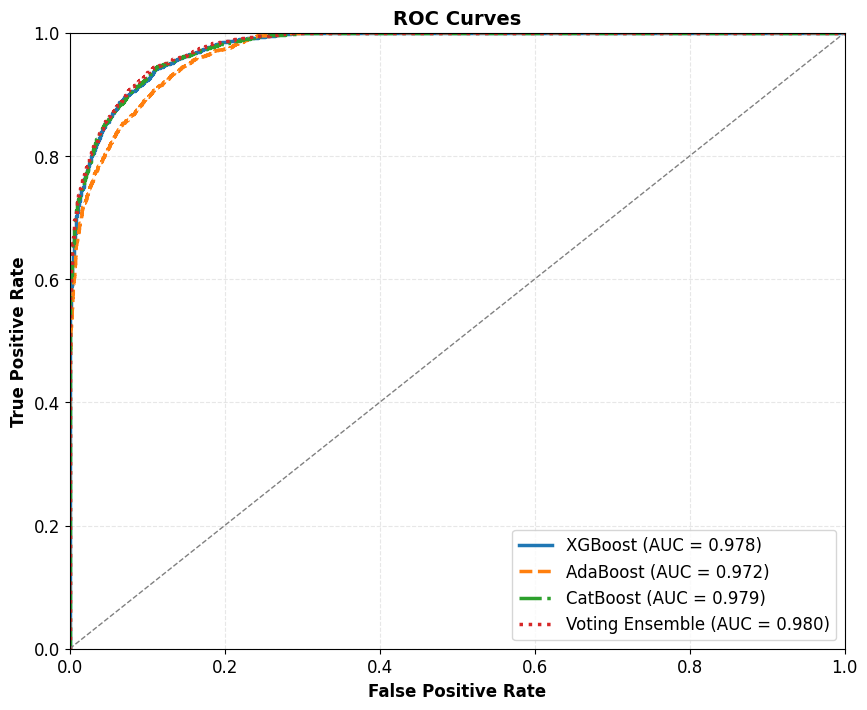

In [69]:
# 创建画布
plt.figure(figsize=(10, 8))
plt.rcParams['font.size'] = 12

# 定义颜色和样式
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
linestyles = ['-', '--', '-.', ':']
models = {
    'XGBoost': best_xgb,
    'AdaBoost': best_adb,
    'CatBoost': best_catb,
    'Voting Ensemble': optimized_voting
}

# 绘制每个模型的ROC曲线
for (name, model), color, ls in zip(models.items(), colors, linestyles):
    # 获取预测概率
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    # 计算ROC指标
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # 绘制曲线
    plt.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2.5, label=f'{name} (AUC = {roc_auc:.3f})')

# 绘制基准线
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

# 添加标注
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", frameon=True)

# 添加网格
plt.grid(True, alpha=0.3, linestyle='--')

plt.show()